In [65]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# ==============================
# CONFIG
# ==============================

NUM_USERS = 500
NUM_PRODUCTS = 100

ACTIONS = [
    "VIEW",
    "CLICK",
    "SEARCH",
    "ADD_TO_CART",
    "REMOVE_FROM_CART",
    "ADD_TO_WISHLIST",
    "PURCHASE"
]

CATEGORIES = ["Mobile", "Laptop"]

# ==============================
# MAP PRODUCT → CATEGORY
# ==============================

product_category_map = {
    i: random.choice(CATEGORIES)
    for i in range(1, NUM_PRODUCTS + 1)
}

# ==============================
# GENERATE DATA
# ==============================

data = []

start_time = datetime(2025, 1, 1)

for user_id in range(1, NUM_USERS + 1):

    current_time = start_time

    favorite_category = random.choice(CATEGORIES)

    for _ in range(random.randint(3, 6)):

        product_id = random.randint(1, NUM_PRODUCTS)
        category = product_category_map[product_id]

        # ===== SEARCH =====
        if random.random() < 0.4:
            current_time += timedelta(minutes=1)
            data.append([user_id, product_id, category, "SEARCH", current_time])

        # ===== VIEW =====
        for _ in range(random.randint(1, 3)):
            current_time += timedelta(minutes=1)
            data.append([user_id, product_id, category, "VIEW", current_time])

        # ===== CLICK =====
        if random.random() < 0.7:
            current_time += timedelta(minutes=1)
            data.append([user_id, product_id, category, "CLICK", current_time])

        # ===== ADD TO CART =====
        cart_prob = 0.6 if category == favorite_category else 0.3
        if random.random() < cart_prob:
            current_time += timedelta(minutes=1)
            data.append([user_id, product_id, category, "ADD_TO_CART", current_time])

            # ===== PURCHASE =====
            purchase_prob = 0.5 if category == favorite_category else 0.2
            if random.random() < purchase_prob:
                current_time += timedelta(minutes=1)
                data.append([user_id, product_id, category, "PURCHASE", current_time])
            else:
                current_time += timedelta(minutes=1)
                data.append([user_id, product_id, category, "REMOVE_FROM_CART", current_time])

        # ===== WISHLIST =====
        if random.random() < 0.3:
            current_time += timedelta(minutes=1)
            data.append([user_id, product_id, category, "ADD_TO_WISHLIST", current_time])

# ==============================
# DATAFRAME
# ==============================

df = pd.DataFrame(data, columns=[
    "user_id",
    "product_id",
    "category",
    "action",
    "timestamp"
])

df = df.sort_values(by=["user_id", "timestamp"])

# ==============================
# SAVE
# ==============================

df.to_csv("data_user500_final.csv", index=False)

print(df.head())
print(df["action"].value_counts())

   user_id  product_id category  action           timestamp
0        1          94   Mobile  SEARCH 2025-01-01 00:01:00
1        1          94   Mobile    VIEW 2025-01-01 00:02:00
2        1          94   Mobile   CLICK 2025-01-01 00:03:00
3        1          86   Mobile    VIEW 2025-01-01 00:04:00
4        1          86   Mobile   CLICK 2025-01-01 00:05:00
action
VIEW                4483
CLICK               1588
ADD_TO_CART         1007
SEARCH               912
ADD_TO_WISHLIST      673
REMOVE_FROM_CART     621
PURCHASE             386
Name: count, dtype: int64


In [7]:
!pip install tensorflow pandas numpy matplotlib scikit-learn jupyter

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.0 kB 325.1 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/61.0 kB 279.3 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 359.6 kB/s eta 0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB 991.0 kB/s eta 0:00:09
   ---------------------------------------- 0.1/8.0 MB 1.1 MB/s eta 0:00:08
    --------------------------------------- 0.1/8.0 MB 1.1 MB/s eta 0:00:08
    --------------------------------------- 0.2/8.0 MB 919.0 kB/s eta 0:00:09
   - -------------------------------------- 0.3/8.0 MB 1.2 MB/s eta 0:00:07
   - -------------------------------------- 0.3/8.0 MB 1.2 MB/s eta 0:00:07
   - -------------------------------------- 0.4/8.0 MB 1.1 MB/s eta 0:00:07
   -- ----


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
#0 - Init


import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


In [66]:
import pandas as pd

# ==============================
# 1. LOAD DATA (đúng file mới)
# ==============================
df = pd.read_csv("data_user500_final.csv")

# đảm bảo đúng kiểu dữ liệu
df["product_id"] = df["product_id"].astype(int)

# ==============================
# 2. ACTION MAP (đúng dataset mới)
# ==============================
action_map = {
    "VIEW": 0,
    "CLICK": 1,
    "SEARCH": 2,
    "ADD_TO_CART": 3,
    "REMOVE_FROM_CART": 4,
    "ADD_TO_WISHLIST": 5,
    "PURCHASE": 6
}

df["action_encoded"] = df["action"].map(action_map)

# ==============================
# 3. PRODUCT (KHÔNG encode lại)
# ==============================
# product đã là số → dùng trực tiếp
df["product_encoded"] = df["product_id"]

# ==============================
# 4. CATEGORY MAP
# ==============================
category_map = {
    "Mobile": 0,
    "Laptop": 1
}

df["category_encoded"] = df["category"].map(category_map)

# ==============================
# 5. CHECK LỖI (RẤT QUAN TRỌNG)
# ==============================
print("Missing action:", df["action_encoded"].isnull().sum())
print("Missing category:", df["category_encoded"].isnull().sum())

# nếu có lỗi → fail ngay
assert df["action_encoded"].isnull().sum() == 0, "Có action chưa map!"
assert df["category_encoded"].isnull().sum() == 0, "Có category chưa map!"

df.head()

Missing action: 0
Missing category: 0


,user_id,product_id,category,action,timestamp,action_encoded,product_encoded,category_encoded
0,1,94,Mobile,SEARCH,2025-01-01 00:01:00,2,94,0
1,1,94,Mobile,VIEW,2025-01-01 00:02:00,0,94,0
2,1,94,Mobile,CLICK,2025-01-01 00:03:00,1,94,0
3,1,86,Mobile,VIEW,2025-01-01 00:04:00,0,86,0
4,1,86,Mobile,CLICK,2025-01-01 00:05:00,1,86,0


In [67]:
sequences_action = []
sequences_product = []
sequences_category = []
labels = []

grouped = df.groupby("user_id")

for user_id, group in grouped:
    group = group.sort_values("timestamp")

    for product_id, sub in group.groupby("product_id"):

        actions = sub["action_encoded"].tolist()
        products = sub["product_encoded"].tolist()
        categories = sub["category_encoded"].tolist()

        # label: có PURCHASE hay không
        label = 1 if action_map["PURCHASE"] in actions else 0

        sequences_action.append(actions)
        sequences_product.append(products)
        sequences_category.append(categories)
        labels.append(label)



In [68]:
max_len = 10

X_action = pad_sequences(sequences_action, maxlen=max_len, padding='post')
X_product = pad_sequences(sequences_product, maxlen=max_len, padding='post')
X_category = pad_sequences(sequences_category, maxlen=max_len, padding='post')

y = np.array(labels)

In [69]:
X_a_train, X_a_test, \
X_p_train, X_p_test, \
X_c_train, X_c_test, \
y_train, y_test = train_test_split(
    X_action, X_product, X_category, y,
    test_size=0.2,
    random_state=42
)

In [13]:
# #RNN
# model_rnn = tf.keras.Sequential([
#     tf.keras.layers.Embedding(input_dim=8, output_dim=16, input_length=max_len),
#     tf.keras.layers.SimpleRNN(32),
#     tf.keras.layers.Dense(1, activation='sigmoid')
# ])

# model_rnn.compile(
#     optimizer='adam',
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )

# history_rnn = model_rnn.fit(
#     X_train, y_train,
#     epochs=10,
#     validation_data=(X_test, y_test)
# )

Epoch 1/10


C:\Users\dinhh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5575 - loss: 0.6834 - val_accuracy: 0.6600 - val_loss: 0.6583
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6175 - loss: 0.6547 - val_accuracy: 0.6700 - val_loss: 0.6125
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6375 - loss: 0.6103 - val_accuracy: 0.8200 - val_loss: 0.5490
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8050 - loss: 0.4752 - val_accuracy: 0.8300 - val_loss: 0.3869
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8500 - loss: 0.3475 - val_accuracy: 0.8800 - val_loss: 0.2953
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8875 - loss: 0.2901 - val_accuracy: 0.8900 - val_loss: 0.2915
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8925 - loss: 0.2623 - val_accuracy: 0.8600 - val_loss: 0.2977
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9125 - loss: 0.2583 - val_accuracy: 0.9100 - val_loss: 0.2512


In [14]:
# #LSTM
# model_lstm = tf.keras.Sequential([
#     tf.keras.layers.Embedding(input_dim=8, output_dim=16, input_length=max_len),
#     tf.keras.layers.LSTM(32),
#     tf.keras.layers.Dense(1, activation='sigmoid')
# ])

# model_lstm.compile(
#     optimizer='adam',
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )

# history_lstm = model_lstm.fit(
#     X_train, y_train,
#     epochs=10,
#     validation_data=(X_test, y_test)
# )

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.5825 - loss: 0.6861 - val_accuracy: 0.6700 - val_loss: 0.6688
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6150 - loss: 0.6655 - val_accuracy: 0.6700 - val_loss: 0.6260
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6150 - loss: 0.6296 - val_accuracy: 0.6700 - val_loss: 0.5625
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6175 - loss: 0.5508 - val_accuracy: 0.7100 - val_loss: 0.4262
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8675 - loss: 0.3681 - val_accuracy: 0.9500 - val_loss: 0.2620
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9575 - loss: 0.2446 - val_accuracy: 0.9600 - val_loss: 0.2022
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9500 - loss: 0.1990 - val_accuracy: 0.9600 - val_loss: 0.1733
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9525 - loss: 0.1774 - val_accuracy: 0.9600 - v

In [70]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Concatenate

action_input = Input(shape=(max_len,))
product_input = Input(shape=(max_len,))
category_input = Input(shape=(max_len,))

action_emb = Embedding(input_dim=len(action_map), output_dim=8)(action_input)
product_emb = Embedding(input_dim=101, output_dim=8)(product_input)  # 100 products
category_emb = Embedding(input_dim=2, output_dim=4)(category_input)

merged = Concatenate()([action_emb, product_emb, category_emb])

x = tf.keras.layers.Bidirectional(LSTM(32))(merged)
output = Dense(1, activation='sigmoid')(x)

model = Model(
    inputs=[action_input, product_input, category_input],
    outputs=output
)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    [X_a_train, X_p_train, X_c_train],
    y_train,
    epochs=10,
    validation_data=([X_a_test, X_p_test, X_c_test], y_test)
)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8119 - loss: 0.4999 - val_accuracy: 0.8215 - val_loss: 0.4250
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8314 - loss: 0.3284 - val_accuracy: 0.9657 - val_loss: 0.1387
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9954 - loss: 0.0520 - val_accuracy: 0.9931 - val_loss: 0.0296
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0075 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 9.6894e-04
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 8.8200e-04 - val_accuracy: 1.0000 - val_loss: 7.0715e-04
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 6.5968e-04 - val_accuracy: 1

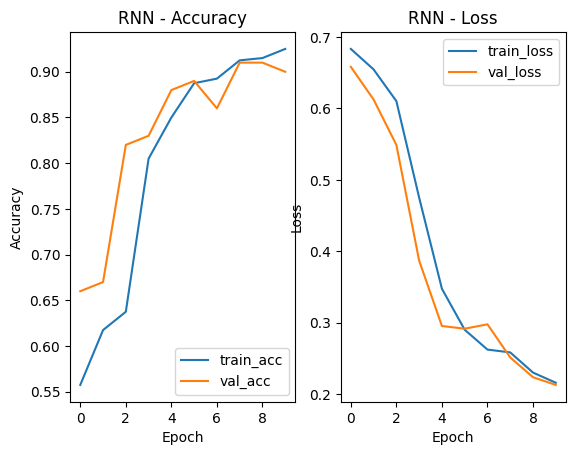

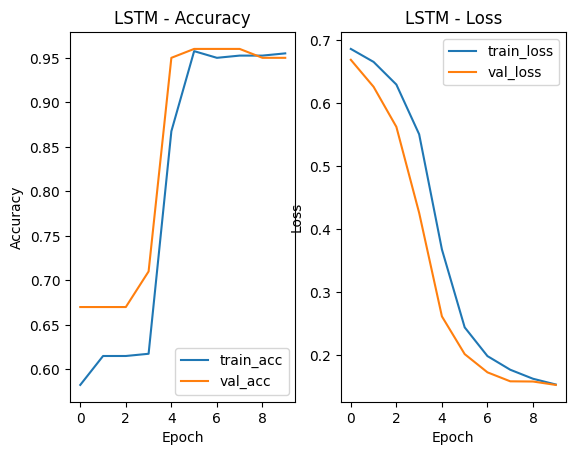

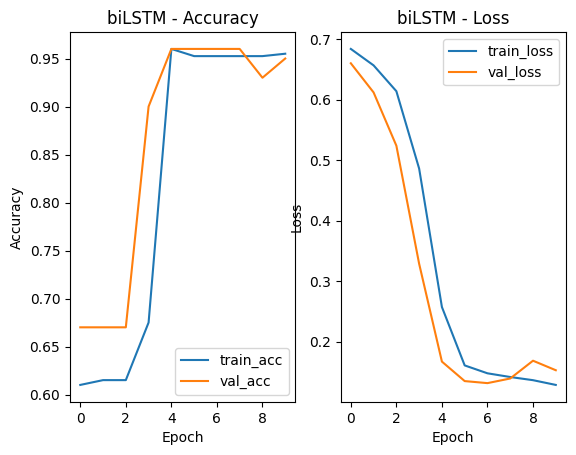

In [17]:
#hien thi 
def plot_full(history, title):
    plt.figure()

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

plot_full(history_rnn, "RNN")
plot_full(history_lstm, "LSTM")
plot_full(history_bilstm, "biLSTM")

In [21]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = (model.predict(X_test) > 0.5).astype(int)

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

evaluate_model(model_rnn, X_test, y_test, "RNN")
evaluate_model(model_lstm, X_test, y_test, "LSTM")
evaluate_model(model_bilstm, X_test, y_test, "biLSTM")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

===== RNN =====
              precision    recall  f1-score   support

           0       0.78      0.97      0.86        33
           1       0.98      0.87      0.92        67

    accuracy                           0.90       100
   macro avg       0.88      0.92      0.89       100
weighted avg       0.92      0.90      0.90       100

Confusion Matrix:
[[32  1]
 [ 9 58]]
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

===== LSTM =====
              precision    recall  f1-score   support

           0       0.89      0.97      0.93        33
           1       0.98      0.94      0.96        67

    accuracy                           0.95       100
   macro avg       0.94      0.95      0.94       100
weighted avg       0.95      0.95      0.95       100

Confusion Matrix:
[[32  1]
 [ 4 63]]
1/4 ━━━━━━━━━━━━━━━━━━━━ 1s 493ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_dat

In [22]:
def get_metrics(model, X_test, y_test):
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    
    from sklearn.metrics import accuracy_score, f1_score
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return acc, f1

rnn_acc, rnn_f1 = get_metrics(model_rnn, X_test, y_test)
lstm_acc, lstm_f1 = get_metrics(model_lstm, X_test, y_test)
bilstm_acc, bilstm_f1 = get_metrics(model_bilstm, X_test, y_test)

print("RNN:", rnn_acc, rnn_f1)
print("LSTM:", lstm_acc, lstm_f1)
print("biLSTM:", bilstm_acc, bilstm_f1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
RNN: 0.9 0.9206349206349206
LSTM: 0.95 0.9618320610687023
biLSTM: 0.95 0.9618320610687023


In [23]:
models = [
    ("RNN", rnn_f1),
    ("LSTM", lstm_f1),
    ("biLSTM", bilstm_f1)
]

best_model = max(models, key=lambda x: x[1])

print("Best model:", best_model)

Best model: ('LSTM', 0.9618320610687023)


In [78]:
model.save("buy_product_prediction_model.keras")

In [79]:
def predict_from_history(user_actions, user_products, user_categories):

    batch_a = []
    batch_p = []
    batch_c = []
    product_list = []
    category_list = []

    product_dict = {}

    for a, p, c in zip(user_actions, user_products, user_categories):
        if p not in product_dict:
            product_dict[p] = {"actions": [], "categories": []}

        product_dict[p]["actions"].append(a)
        product_dict[p]["categories"].append(c)

    # build batch
    for product, data in product_dict.items():

        actions = [action_map[x] for x in data["actions"]]
        categories = [category_map[x] for x in data["categories"]]

        # 👉 lấy category cuối (gần nhất)
        category_name = data["categories"][-1]

        products = [product] * len(actions)

        a = pad_sequences([actions], maxlen=max_len, padding='post')[0]
        p = pad_sequences([products], maxlen=max_len, padding='post')[0]
        c = pad_sequences([categories], maxlen=max_len, padding='post')[0]

        batch_a.append(a)
        batch_p.append(p)
        batch_c.append(c)

        product_list.append(product)
        category_list.append(category_name)

    # convert numpy
    batch_a = np.array(batch_a)
    batch_p = np.array(batch_p)
    batch_c = np.array(batch_c)

    # predict 1 lần
    probs = model.predict([batch_a, batch_p, batch_c], verbose=0)

    # 👉 format output rõ ràng
    results = []

    for i in range(len(product_list)):
        results.append({
            "product_id": product_list[i],
            "category": category_list[i],
            "probability": float(probs[i][0])
        })

    # 👉 sort theo xác suất cao → thấp
    results = sorted(results, key=lambda x: x["probability"], reverse=True)

    return results

In [80]:
actions = ["VIEW", "CLICK", "ADD_TO_CART", "VIEW", "CLICK"]
products = [1, 1, 1, 5, 5]
categories = ["Mobile", "Mobile", "Mobile", "Laptop", "Laptop"]

result = predict_from_history(actions, products, categories)

print(result)

[{'product_id': 1, 'category': 'Mobile', 'probability': 0.8492652773857117}, {'product_id': 5, 'category': 'Laptop', 'probability': 7.086737605277449e-05}]
